vetor v1 =  [3. 2.]
vetor v2 =  [1. 4.]
norma de v1 (manual) =  3.605551275463989
norma de v1 (numpy) =  3.605551275463989
norma L1 de v1 =  5.0
vetor unitário de v1 =  [0.83205029 0.5547002 ]
produto interno (manual) =  11.0
produto interno (numpy) =  11.0
produto interno (operador @) =  11.0

cos(v2, paralelo):  0.9762  ← esperado: 1.0
cos(v2, oposto):    -1.0000  ← esperado: -1.0
cos(v2, ortogonal): 0.0000  ← esperado: 0.0

Projeção de v1 em v2: 2.6679

Similaridade entre a query e os documentos:
doc1 (esperado: mais similar): 0.9901
doc2 (esperado: menos similar): 0.3333
doc3 (esperado: menos similar): 0.0000


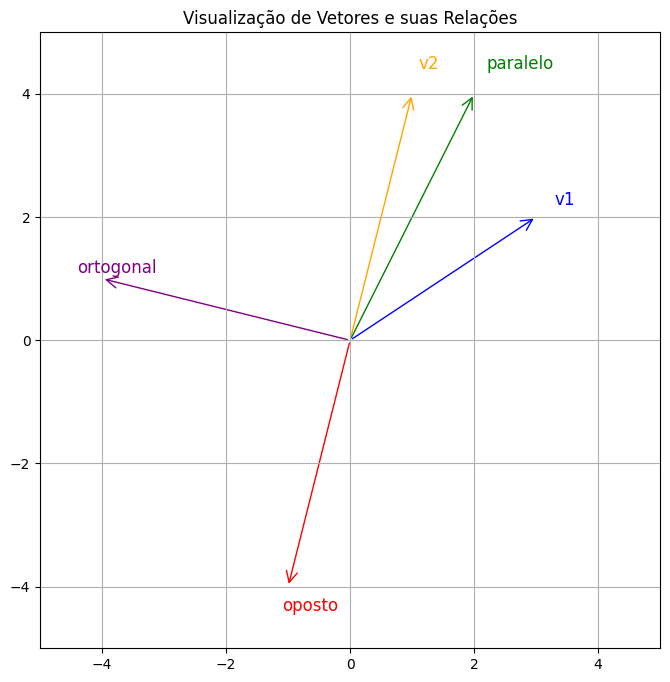

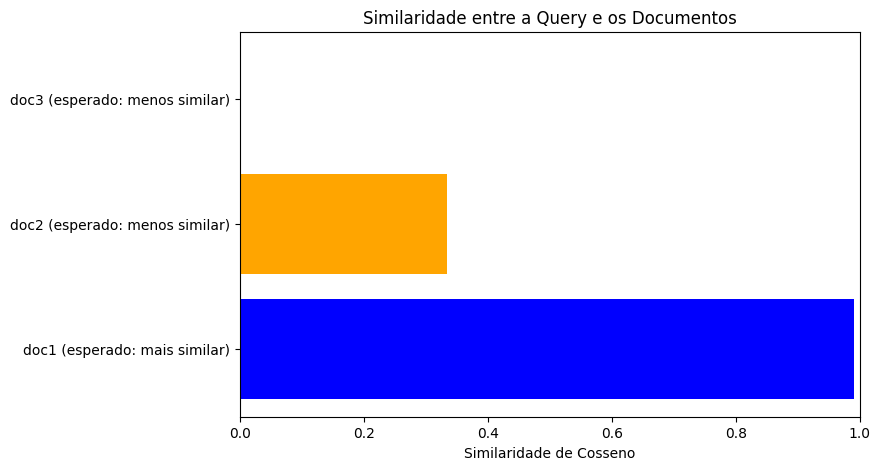

In [15]:
# commit 1 - vetores, normas e produto interno

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# vetores
v1 = np.array([3.0, 2.0])
v2 = np.array([1.0, 4.0])

print("vetor v1 = ", v1)
print("vetor v2 = ", v2)

# norma -->> ||v1|| = sqrt(v1[0]**2 + v1[1]**2)
# distancia euclidiana calculando na mão e com a função np.linalg.norm
norma_v1_manual = np.sqrt(v1[0]**2 + v1[1]**2) # ou np.sqrt(np.sum(v1**2)) generalizando para N dimensões
norma_v1_roubando = np.linalg.norm(v1)

print("norma de v1 (manual) = ", norma_v1_manual)
print("norma de v1 (numpy) = ", norma_v1_roubando)

# Norma L1 de manhattan regularização Lasso representa a soma da magnetudes dos elementos do vetor
norma_L1_v1 = np.sum(np.abs(v1))
print("norma L1 de v1 = ", norma_L1_v1)

# vetor unitário
v1_unitario = v1 / norma_v1_manual
print("vetor unitário de v1 = ", v1_unitario)


# produto interno
#representa o quanto de um vetor está na direção do outro ou quanto eles concordam em direção
dot_manual = np.sum(v1 * v2) # ou v1[0]*v2[0] + v1[1]*v2[1]
dot_roubando = np.dot(v1, v2)
dot_at = v1 @ v2 #operador @ é o mesmo que np.dot para vetores
print("produto interno (manual) = ", dot_manual)
print("produto interno (numpy) = ", dot_roubando)
print("produto interno (operador @) = ", dot_at)

# ângulo entre os vetores
# v1 . v2 / v1 * v2
# # podemos estudar a similaridade entre os vetores usando o produto interno e as normas
# fazemos isso normalizando o vetor (extremamente para comparar coisas  de magnetudes diferentes)
cos_theta = (v1 @ v2) / (np.sqrt(np.sum(v1**2)) * np.sqrt(np.sum(v2**2)))
theta_rad = np.arccos(cos_theta) # ângulo em radianos

#ou em função
def cosine_similarity(v1, v2):
    """Similaridade de cosseno entre dois vetores."""
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))


# estudando alguns caosos

# Casos extremos — intuição
v_paralelo  = np.array([2.0, 4.0])   # mesma direção de b
v_oposto    = np.array([-1.0, -4.0]) # oposto de b
v_ortogonal = np.array([-4.0, 1.0])  # perpendicular a b (dot=0)

print(f"\ncos(v2, paralelo):  {cosine_similarity(v2, v_paralelo):.4f}  ← esperado: 1.0")
print(f"cos(v2, oposto):    {cosine_similarity(v2, v_oposto):.4f}  ← esperado: -1.0")
print(f"cos(v2, ortogonal): {cosine_similarity(v2, v_ortogonal):.4f}  ← esperado: 0.0")

# projetando direções, quanto de v1 está na direção de v2
projecao_v1_em_v2 = (v1 @ v2) / np.linalg.norm(v2) # magnitude da projeção
print(f"\nProjeção de v1 em v2: {projecao_v1_em_v2:.4f}")

# exemplo de aplicação: similaridade entre documentos usando vetores de palavras
doc1 = np.array([3, 2, 2, 0, 0])  # vetor de contagem de palavras para o documento 1
doc2 = np.array([0, 1, 1, 2, 0])
doc3 = np.array([0, 0, 0, 1, 3])  

query = np.array([2, 1, 1, 0, 0])

sims = {
    "doc1 (esperado: mais similar)": cosine_similarity(query, doc1),
    "doc2 (esperado: menos similar)": cosine_similarity(query, doc2),
    "doc3 (esperado: menos similar)": cosine_similarity(query, doc3),
}

print("\nSimilaridade entre a query e os documentos:")
for nome, sim in sorted(sims.items(), key=lambda x: -x[1]):
    print(f"{nome}: {sim:.4f}")

# vizualizando tudo
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.grid()
# função para desenhar vetores
def draw_vector(v, color, label):
    ax.add_patch(FancyArrowPatch((0, 0), v, color=color, arrowstyle='->', mutation_scale=20))
    ax.text(v[0] * 1.1, v[1] * 1.1, label, fontsize=12, color=color)
# desenhando os vetores
draw_vector(v1, 'blue', 'v1')
draw_vector(v2, 'orange', 'v2')
draw_vector(v_paralelo, 'green', 'paralelo')
draw_vector(v_oposto, 'red', 'oposto')
draw_vector(v_ortogonal, 'purple', 'ortogonal')
plt.title("Visualização de Vetores e suas Relações")
plt.show()

#plotadno a similaridade entre a query e os documentos
doc_labels = list(sims.keys())
doc_values = list(sims.values())
plt.figure(figsize=(8, 5))
plt.barh(doc_labels, doc_values, color=['blue', 'orange', 'green'])
plt.xlabel("Similaridade de Cosseno")
plt.title("Similaridade entre a Query e os Documentos")
plt.xlim(0, 1)
plt.show()









